--- Hierarchical Dataset Audit ---
Total Observations: 1000
Features Detected:  ['property_type', 'n_rooms', 'dist_centre_km', 'outdoor_space', 'near_underground', 'intercept', 'beta_room', 'beta_dist', 'beta_under', 'beta_prop', 'beta_outdoor', 'premium', 'monthly_rent_gbp', 'listing_type']
------------------------------
Injected Agent Premium Mean:  0.1500
Injected Agent Premium Sigma: 0.0420


,property_type,n_rooms,dist_centre_km,outdoor_space,near_underground,intercept,beta_room,beta_dist,beta_under,beta_prop,beta_outdoor,premium,monthly_rent_gbp,listing_type
0,Flat,4,2.191222,Nothing,0,7.511921,0.165528,-0.055014,0.000000,0.000000,0.000000,0.0,3338.647763,Owner
1,House,5,7.575474,Nothing,0,7.496682,0.156869,-0.045599,0.000000,0.257551,0.000000,0.0,3570.013884,Owner
2,Flat,5,4.149337,Nothing,1,7.515545,0.134727,-0.013805,0.118006,0.000000,0.000000,0.0,4352.087688,Owner
3,Flat,4,1.513386,Garden,0,7.536553,0.312587,-0.074508,0.000000,0.000000,0.152704,0.0,6632.427753,Owner
4,Flat,2,5.936449,Nothing,0,7.494380,0.160696,-0.038940,0.000000,0.000000,0.000000,0.0,2050.803861,Owner


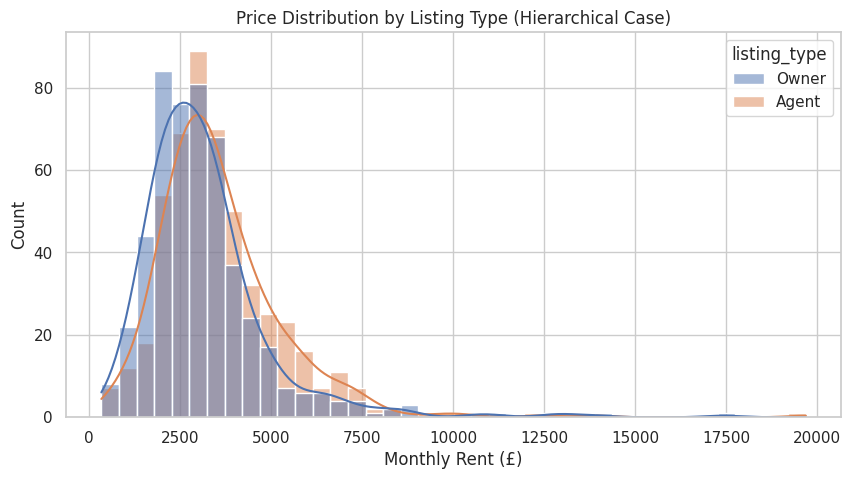

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import json
from scipy.stats import gamma

# --- 1. LOAD HIERARCHICAL DATA ---
# Since Hierarchical mode uses JSON to store nested metadata + properties
file_path = "../../data/datasets/london_rentals_hierarchical.json"

with open(file_path, 'r') as f:
    payload = json.load(f)

# Extract the "Answer Key" for the Market
owner_market = payload['metadata']['owner_market_truth']
agent_market = payload['metadata']['agent_market_truth']

# Extract the "Observations" for the EDA
df = pd.DataFrame(payload['properties'])

# --- 2. INITIAL DATA AUDIT ---
print(f"--- Hierarchical Dataset Audit ---")
print(f"Total Observations: {len(df)}")
print(f"Features Detected:  {list(df.columns)}")
print("-" * 30)

# Quick check on the Agent Premium in the ground truth
print(f"Injected Agent Premium Mean:  {agent_market['means']['premium']:.4f}")
print(f"Injected Agent Premium Sigma: {agent_market['sigmas']['premium']:.4f}")

# Display first few rows to see individual property betas
display(df.head())

# --- 3. BASIC LOG-PRICE DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='monthly_rent_gbp', hue='listing_type', kde=True, bins=40)
plt.title("Price Distribution by Listing Type (Hierarchical Case)")
plt.xlabel("Monthly Rent (£)")
plt.show()

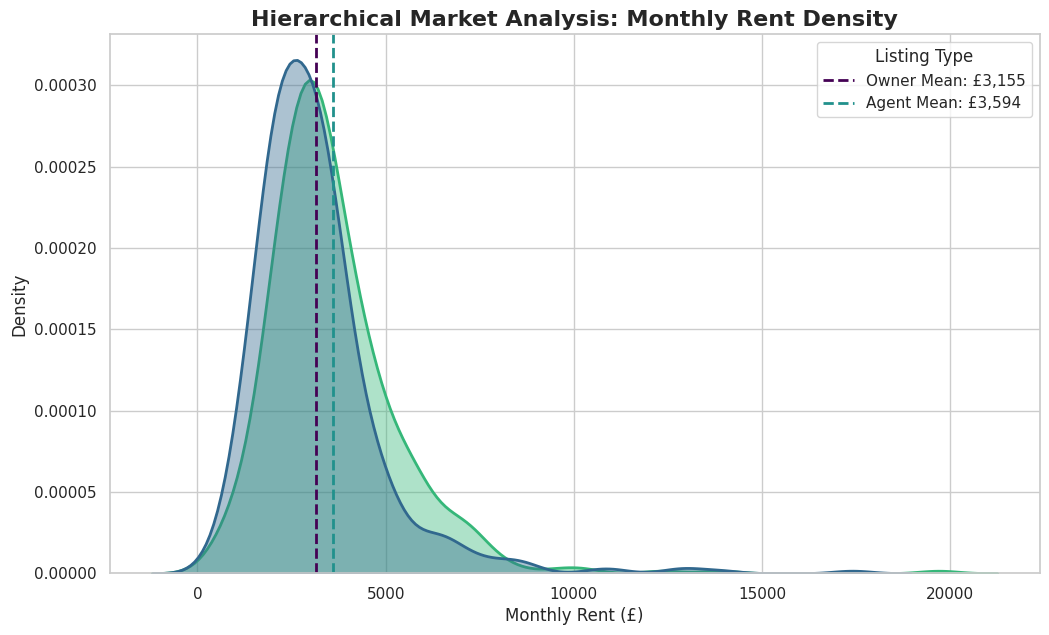

--- Hierarchical Price Summary ---
                  mean    median       std  count  coeff_variation  markup_pct
listing_type                                                                  
Agent         3593.881  3249.252  1795.719    500            0.500      13.912
Owner         3154.953  2860.564  1775.651    500            0.563       0.000


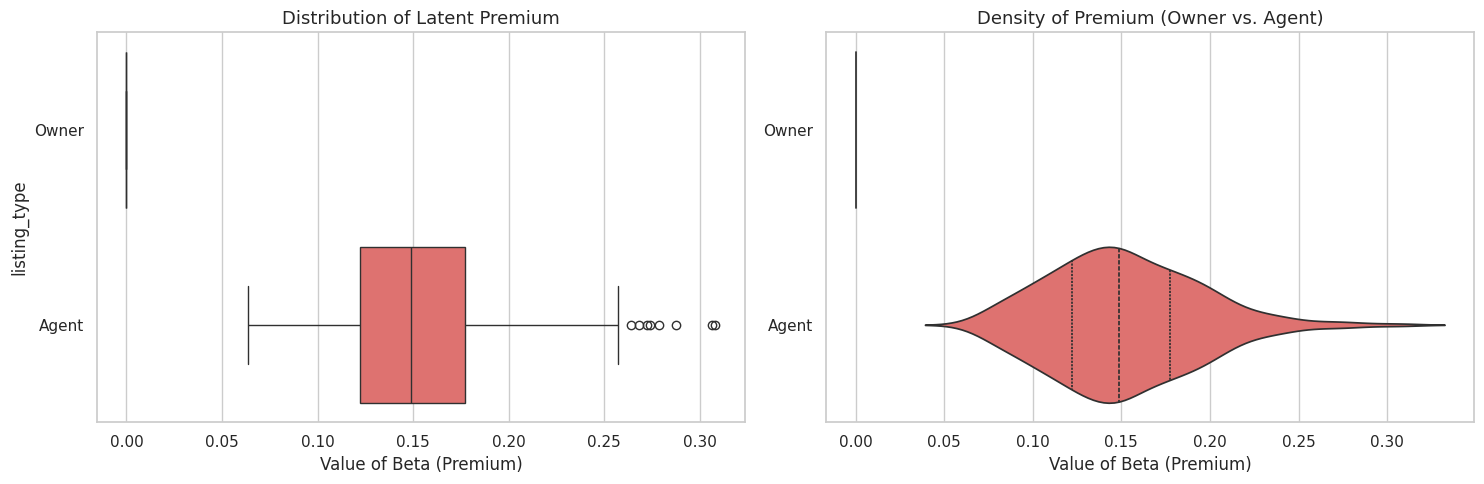

--- Owner Premium Audit ---
Mean: 0.0000 | Max: 0.0000
Status: Verified clean. No 'Premium' noise in Owner group.


In [10]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 1. Plot the distribution of prices
# Hierarchical data often shows wider tails, so KDE is great here
ax = sns.kdeplot(
    data=df, x='monthly_rent_gbp', hue='listing_type', 
    fill=True, common_norm=False, palette='viridis', alpha=0.4, linewidth=2
)

# Calculate means for the lines
owner_mean = df[df['listing_type']=='Owner']['monthly_rent_gbp'].mean()
agent_mean = df[df['listing_type']=='Agent']['monthly_rent_gbp'].mean()

# Add vertical lines with labels for the means
plt.axvline(owner_mean, color='#440154', linestyle='--', linewidth=2, label=f'Owner Mean: £{owner_mean:,.0f}')
plt.axvline(agent_mean, color='#21918c', linestyle='--', linewidth=2, label=f'Agent Mean: £{agent_mean:,.0f}')

plt.title('Hierarchical Market Analysis: Monthly Rent Density', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Rent (£)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Move legend to a clean spot
plt.legend(title="Listing Type", loc='upper right')
plt.show()

# 2. Advanced Summary Statistics
# We include Coefficient of Variation (std/mean) to see which group has more 'internal' volatility
summary = df.groupby('listing_type')['monthly_rent_gbp'].agg(['mean', 'median', 'std', 'count'])
summary['coeff_variation'] = summary['std'] / summary['mean']
summary['markup_pct'] = (summary['mean'] / summary.loc['Owner', 'mean'] - 1) * 100

print("--- Hierarchical Price Summary ---")
print(summary.round(3))

# --- 3. THE HIERARCHICAL "TELL" ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot - Using the new 'hue' logic to avoid warnings
sns.boxplot(
    data=df, x='premium', y='listing_type', 
    hue='listing_type', palette='magma', 
    legend=False, ax=axes[0]
)
axes[0].set_title("Distribution of Latent Premium", fontsize=13)
axes[0].set_xlabel("Value of Beta (Premium)")

# 2. Violin plot - Same update here
sns.violinplot(
    data=df, x='premium', y='listing_type', 
    hue='listing_type', palette='magma', 
    inner="quart", legend=False, ax=axes[1]
)
axes[1].set_title("Density of Premium (Owner vs. Agent)", fontsize=13)
axes[1].set_xlabel("Value of Beta (Premium)")
axes[1].set_ylabel("") 

plt.tight_layout()
plt.show()

# Numerical Verification
owner_prem = df[df['listing_type']=='Owner']['premium']
print(f"--- Owner Premium Audit ---")
print(f"Mean: {owner_prem.mean():.4f} | Max: {owner_prem.max():.4f}")
if owner_prem.max() < 1e-10:
    print("Status: Verified clean. No 'Premium' noise in Owner group.")

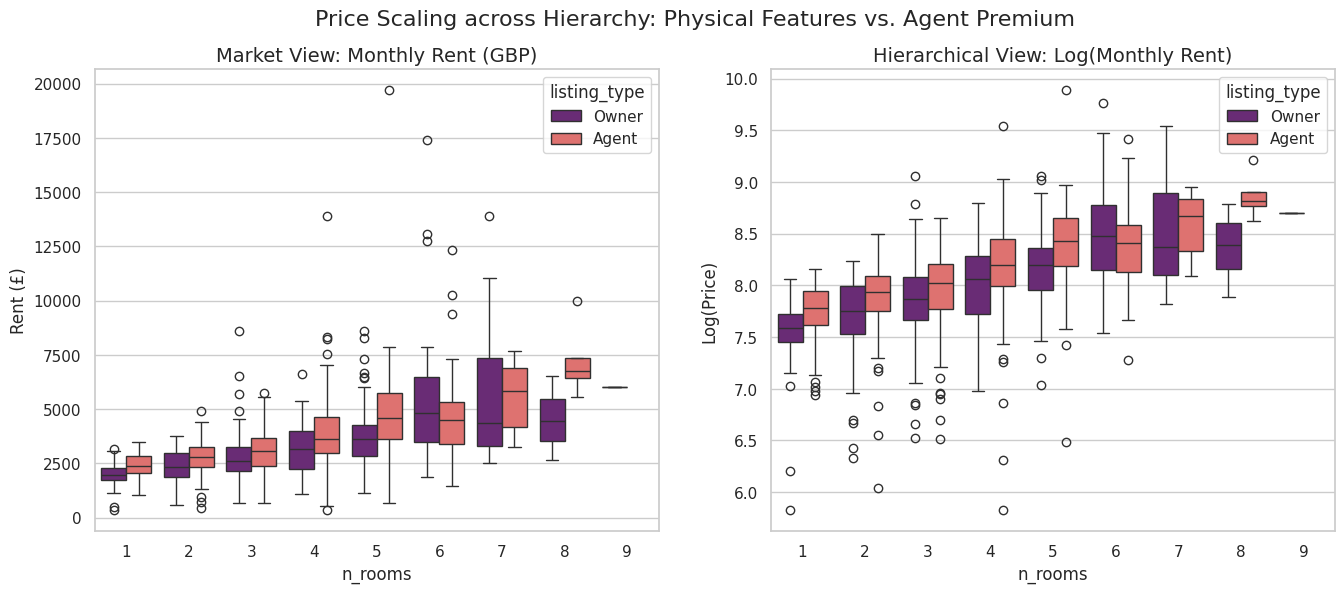

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Linear Scale - The "Customer Experience"
sns.boxplot(
    data=df, x='n_rooms', y='monthly_rent_gbp', hue='listing_type', 
    palette='magma', hue_order=['Owner', 'Agent'], ax=axes[0]
)
axes[0].set_title('Market View: Monthly Rent (GBP)', fontsize=14)
axes[0].set_ylabel('Rent (£)')

# 2. Log Scale - The "Model Logic" 
# This shows the underlying linear structure: log(Price) = beta_0 + beta_room * rooms + premium
sns.boxplot(
    data=df, x='n_rooms', y=np.log(df['monthly_rent_gbp']), hue='listing_type', 
    palette='magma', hue_order=['Owner', 'Agent'], ax=axes[1]
)
axes[1].set_title('Hierarchical View: Log(Monthly Rent)', fontsize=14)
axes[1].set_ylabel('Log(Price)')

plt.suptitle("Price Scaling across Hierarchy: Physical Features vs. Agent Premium", fontsize=16)
plt.show()

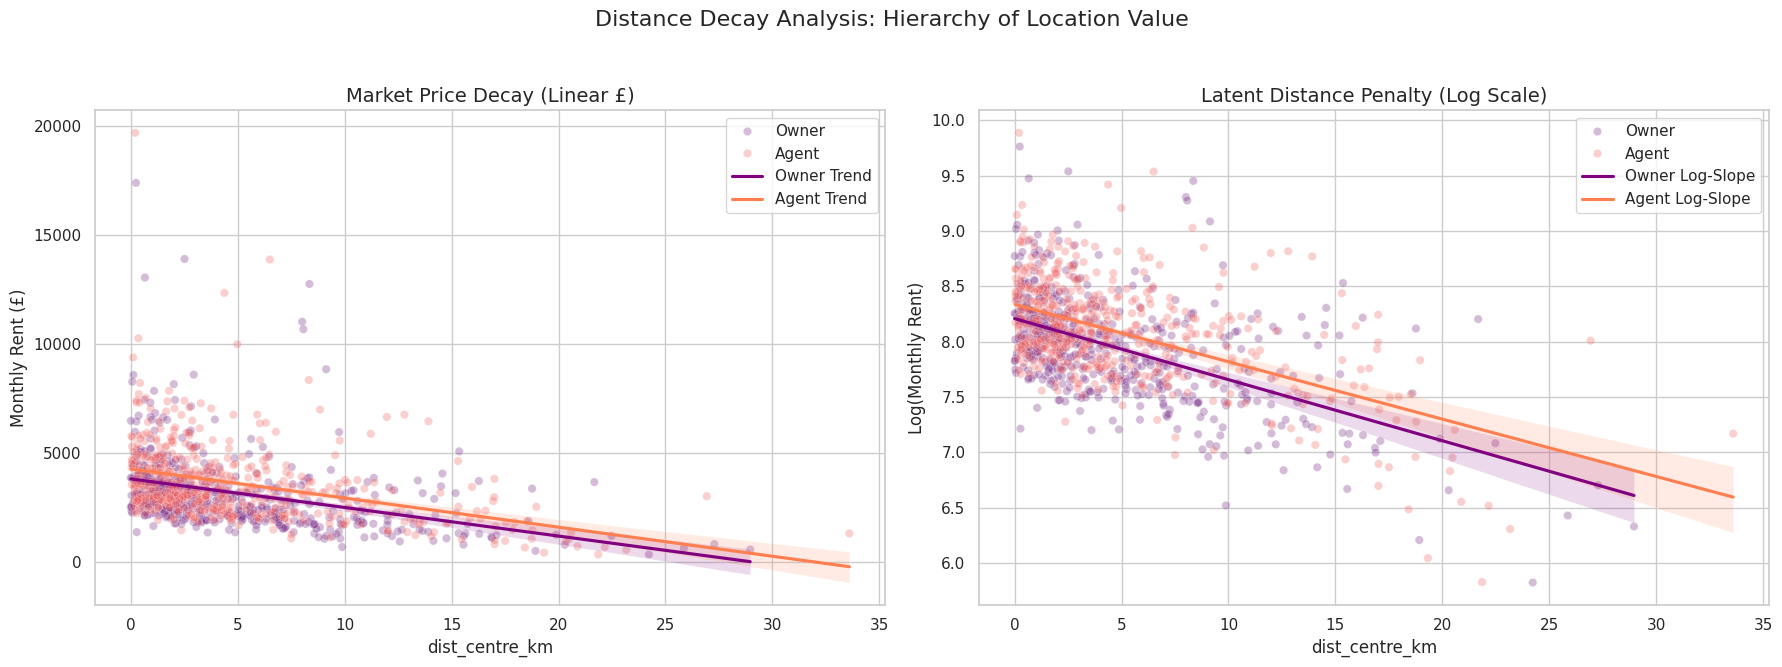

In [12]:
# Create a side-by-side comparison: Linear vs Log
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 1. Linear Scale ---
sns.scatterplot(data=df, x='dist_centre_km', y='monthly_rent_gbp', 
                hue='listing_type', hue_order=['Owner', 'Agent'],
                palette='magma', alpha=0.3, ax=axes[0])

# Separate dataframes for clean plotting
df_owner = df[df['listing_type']=='Owner']
df_agent = df[df['listing_type']=='Agent']

sns.regplot(data=df_owner, x='dist_centre_km', y='monthly_rent_gbp', 
            scatter=False, color='purple', label='Owner Trend', ax=axes[0])
sns.regplot(data=df_agent, x='dist_centre_km', y='monthly_rent_gbp', 
            scatter=False, color='coral', label='Agent Trend', ax=axes[0])

axes[0].set_title('Market Price Decay (Linear £)', fontsize=14)
axes[0].set_ylabel('Monthly Rent (£)')
axes[0].legend()

# --- 2. Log Scale ---
# We calculate log_rent as a temporary column to ensure indices match perfectly
df['log_rent'] = np.log(df['monthly_rent_gbp'])

sns.scatterplot(data=df, x='dist_centre_km', y='log_rent', 
                hue='listing_type', hue_order=['Owner', 'Agent'],
                palette='magma', alpha=0.3, ax=axes[1])

# Re-filter after adding the column
sns.regplot(data=df[df['listing_type']=='Owner'], x='dist_centre_km', y='log_rent', 
            scatter=False, color='purple', label='Owner Log-Slope', ax=axes[1])
sns.regplot(data=df[df['listing_type']=='Agent'], x='dist_centre_km', y='log_rent', 
            scatter=False, color='coral', label='Agent Log-Slope', ax=axes[1])

axes[1].set_title('Latent Distance Penalty (Log Scale)', fontsize=14)
axes[1].set_ylabel('Log(Monthly Rent)')
axes[1].legend()

plt.suptitle("Distance Decay Analysis: Hierarchy of Location Value", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

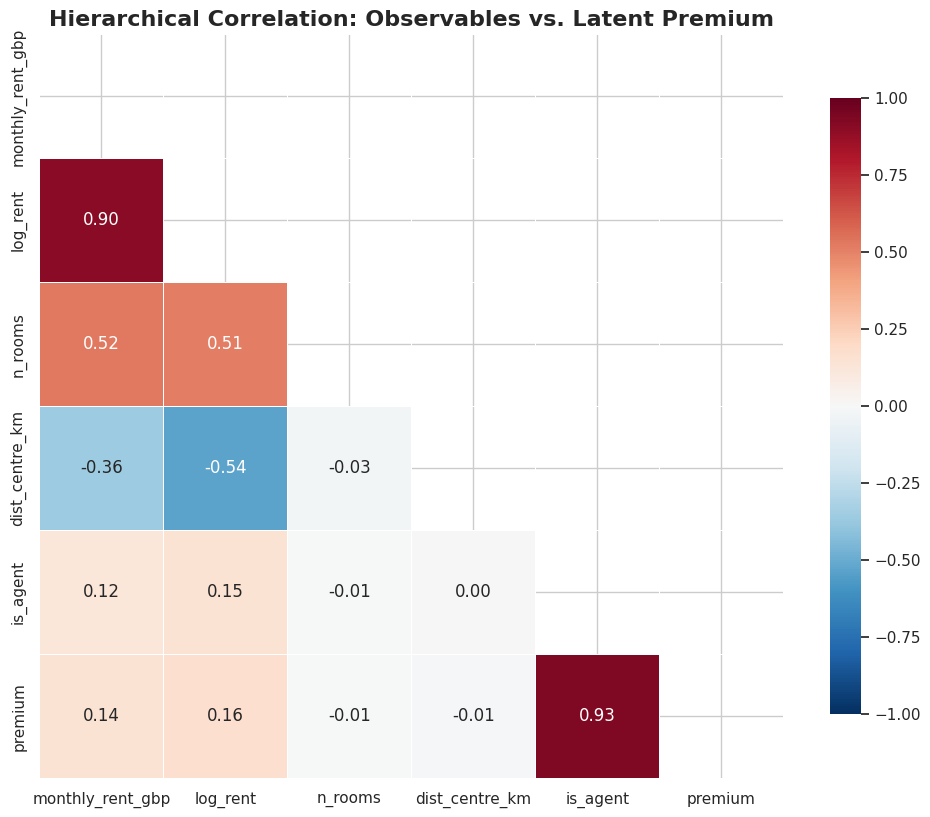

In [13]:
# --- HIERARCHICAL CORRELATION ANALYSIS ---

# 1. Prepare the dataframe
df_corr = df.copy()
df_corr['is_agent'] = (df['listing_type'] == 'Agent').astype(int)

# 2. Separate variables into 'Observables' and 'Latent Parameters'
# We want to see how the hidden premium relates to the physical house
target_cols = [
    'monthly_rent_gbp', 'log_rent',             # Outcomes
    'n_rooms', 'dist_centre_km', 'is_agent',    # Observables
    'premium'                                   # The Latent Hierarchy
]

# Ensure we only use columns that actually exist
existing_cols = [c for c in target_cols if c in df_corr.columns]
correlation_matrix = df_corr[existing_cols].corr()

# 3. Plotting
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Mask the upper triangle for clarity

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='RdBu_r', # Red-Blue is great for seeing positive/negative divergence
    fmt=".2f", 
    mask=mask, 
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Hierarchical Correlation: Observables vs. Latent Premium', fontsize=16, fontweight='bold')
plt.show()

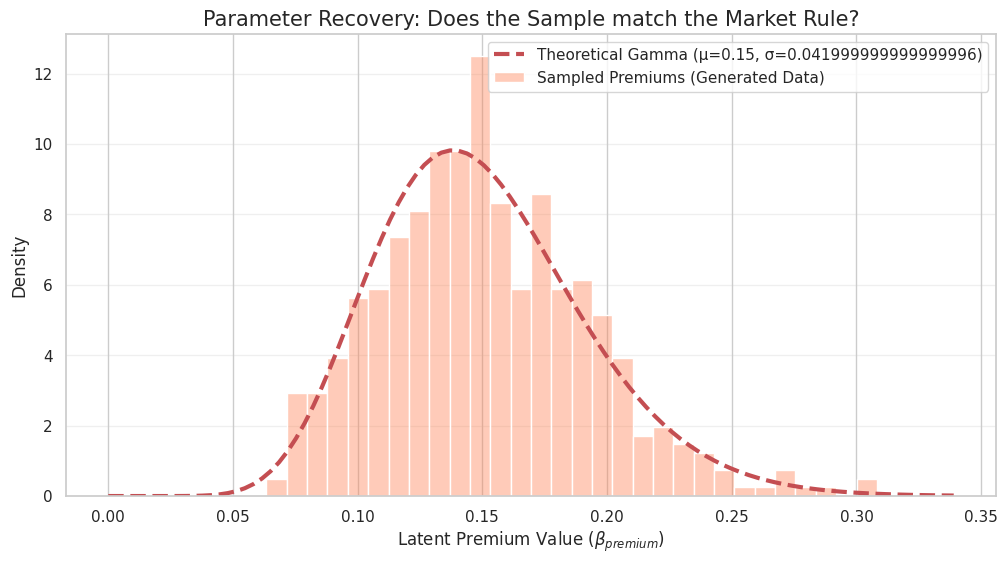

--- Numerical Audit ---
Target Mean: 0.1500 | Observed Mean: 0.1514
Target Std:  0.0420 | Observed Std:  0.0420


In [15]:
# --- TEST 1: PARAMETER RECOVERY (TRUTH CALIBRATION) ---

# 1. Extract the generated premiums for Agents
agent_premiums = df[df['listing_type'] == 'Agent']['premium']

# 2. Define the theoretical parameters used in generator
# alpha = (mean/sigma)**2 | beta = mean/(sigma**2)
m_mean = 0.15 
m_sigma = 0.03*1.4
shape_alpha = (m_mean / m_sigma)**2
scale_theta = (m_sigma**2) / m_mean

# 3. Create the Plot
plt.figure(figsize=(12, 6))

# Plot the Actual Data (The "Sample")
sns.histplot(agent_premiums, bins=30, stat="density", color="coral", 
             alpha=0.4, label="Sampled Premiums (Generated Data)")

# Plot the Theoretical Curve (The "Market Rule")
x = np.linspace(0, agent_premiums.max() * 1.1, 100)
y = gamma.pdf(x, a=shape_alpha, scale=scale_theta)
plt.plot(x, y, 'r--', lw=3, label=f'Theoretical Gamma (μ={m_mean}, σ={m_sigma})')

# Formatting
plt.title("Parameter Recovery: Does the Sample match the Market Rule?", fontsize=15)
plt.xlabel("Latent Premium Value ($\\beta_{premium}$)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# 4. Numerical Validation
print(f"--- Numerical Audit ---")
print(f"Target Mean: {m_mean:.4f} | Observed Mean: {agent_premiums.mean():.4f}")
print(f"Target Std:  {m_sigma:.4f} | Observed Std:  {agent_premiums.std():.4f}")

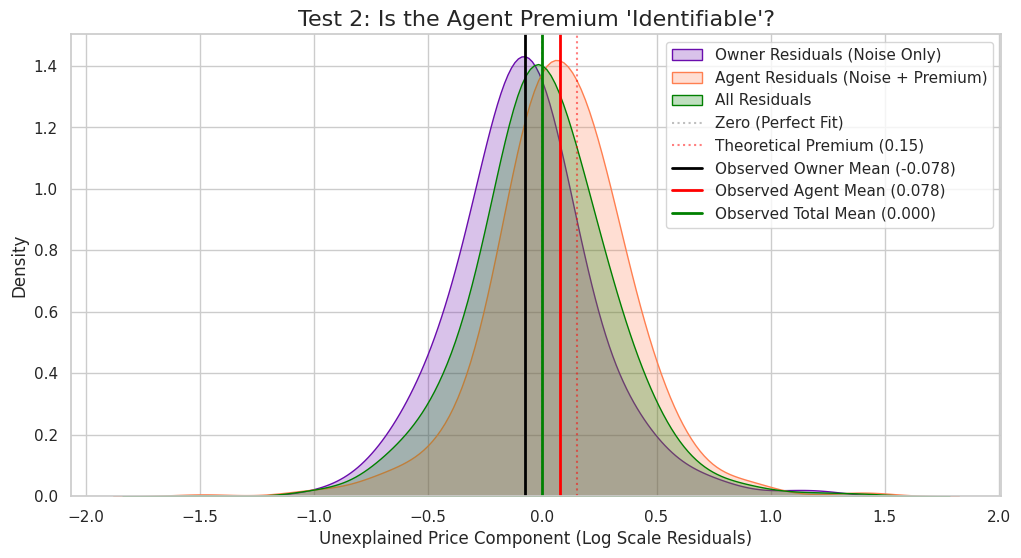

--- Recovered Physical Betas (OLS) ---
const               7.593088
n_rooms             0.153438
dist_centre_km     -0.052572
near_underground    0.110197
is_house            0.162059
has_garden          0.136833
has_terrace         0.092803
has_balcony         0.112804
dtype: float64

Distance between Observed Means: 0.1563


In [40]:
# 1. Feature Engineering
df["is_house"] = (df["property_type"] == "House").astype(int)
df["has_garden"] = (df["outdoor_space"] == "Garden").astype(int)
df["has_terrace"] = (df["outdoor_space"] == "Terrace").astype(int)
df["has_balcony"] = (df["outdoor_space"] == "Balcony").astype(int)

# 2. Select physical features
physical_features = [
    'n_rooms', 'dist_centre_km', 'near_underground',
    'is_house', 'has_garden', 'has_terrace', 'has_balcony'
]

# 3. Setup and Fit OLS
X = sm.add_constant(df[physical_features].astype(float))
y = np.log(df['monthly_rent_gbp'])
clean_model = sm.OLS(y, X).fit()

# 4. Extract Residuals
df['clean_residuals'] = y - clean_model.predict(X)

# 5. Calculate Residual Means for plotting
owner_mean_res = df[df['listing_type']=='Owner']['clean_residuals'].mean()
agent_mean_res = df[df['listing_type']=='Agent']['clean_residuals'].mean()
mean_res = df['clean_residuals'].mean()

# 6. Visualize
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['listing_type']=='Owner'], x='clean_residuals', 
            fill=True, color='#6A0DAD', label='Owner Residuals (Noise Only)', bw_adjust=1.5)
sns.kdeplot(data=df[df['listing_type']=='Agent'], x='clean_residuals', 
            fill=True, color='#FF7F50', label='Agent Residuals (Noise + Premium)', bw_adjust=1.5)
sns.kdeplot(data=df, x='clean_residuals', 
            fill=True, color='green', label='All Residuals', bw_adjust=1.5)

# Reference Lines
plt.axvline(0, color='grey', linestyle=':', alpha=0.5, label='Zero (Perfect Fit)')
plt.axvline(0.15, color='red', linestyle=':', alpha=0.5, label='Theoretical Premium (0.15)')

# Observed Mean Lines (Solid as requested)
plt.axvline(owner_mean_res, color='black', linestyle='-', linewidth=2, 
            label=f'Observed Owner Mean ({owner_mean_res:.3f})')
plt.axvline(agent_mean_res, color='red', linestyle='-', linewidth=2, 
            label=f'Observed Agent Mean ({agent_mean_res:.3f})')
plt.axvline(mean_res, color='green', linestyle='-', linewidth=2, 
            label=f'Observed Total Mean ({mean_res:.3f})')

plt.title("Test 2: Is the Agent Premium 'Identifiable'?", fontsize=16)
plt.xlabel("Unexplained Price Component (Log Scale Residuals)")
plt.ylabel("Density")
plt.legend()
plt.show()

# 7. Diagnostics
print("--- Recovered Physical Betas (OLS) ---")
print(clean_model.params)
print(f"\nDistance between Observed Means: {agent_mean_res - owner_mean_res:.4f}")

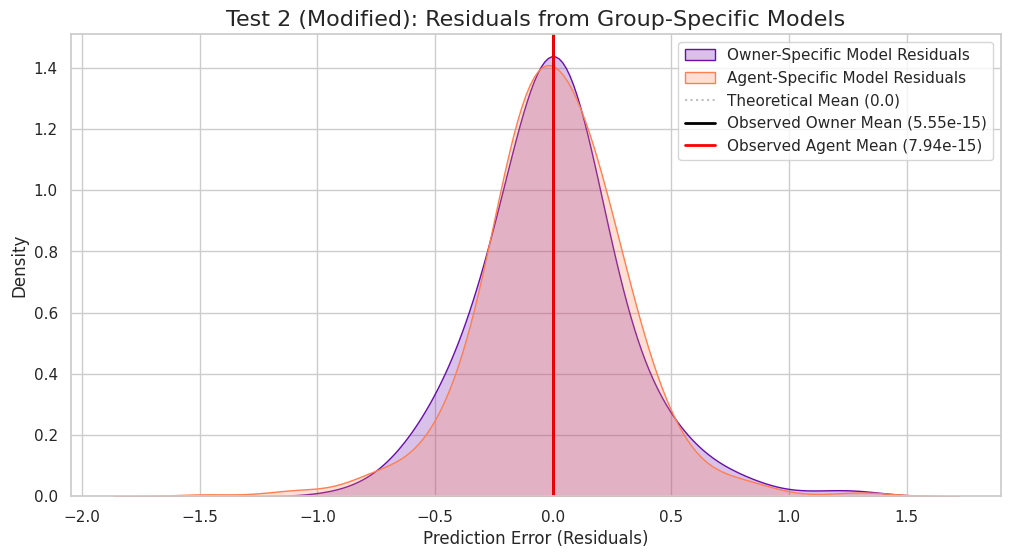

--- Beta Recovery Comparison ---
                  True Mean  Recovered (O)    SE (O)  Recovered (A)    SE (A)
const                  7.50       7.489412  0.041137       7.693971  0.041320
n_rooms                0.15       0.152271  0.008535       0.155823  0.009009
dist_centre_km        -0.05      -0.050858  0.002867      -0.053828  0.002717
near_underground       0.10       0.105502  0.029775       0.133747  0.031467
is_house               0.20       0.205167  0.031222       0.129609  0.032875
has_garden             0.15       0.155119  0.032308       0.113141  0.033708
has_terrace            0.10       0.129430  0.038011       0.031472  0.036107
has_balcony            0.05       0.094215  0.054446       0.089947  0.049030

Captured Agent Intercept Shift (Target ~0.15): 0.2046(±0.1143 at 95% CI)


In [39]:
# 1. Setup Features
physical_features = ['n_rooms', 'dist_centre_km', 'near_underground', 
                     'is_house', 'has_garden', 'has_terrace', 'has_balcony']

def get_ols_results(data_subset):
    X = sm.add_constant(data_subset[physical_features].astype(float))
    y = np.log(data_subset['monthly_rent_gbp'])
    model = sm.OLS(y, X).fit()
    residuals = y - model.predict(X)
    return model, residuals

# 2. Perform OLS separately for each group
owner_model, owner_res = get_ols_results(df[df['listing_type'] == 'Owner'])
agent_model, agent_res = get_ols_results(df[df['listing_type'] == 'Agent'])

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.kdeplot(owner_res, fill=True, color='#6A0DAD', label='Owner-Specific Model Residuals', bw_adjust=1.5)
sns.kdeplot(agent_res, fill=True, color='#FF7F50', label='Agent-Specific Model Residuals', bw_adjust=1.5)

# Theoretical Means (Zero for both in this specific local-fit context)
# Since the premium is now in the coefficients, the residual target for both is 0
plt.axvline(0, color='grey', linestyle=':', alpha=0.5, label='Theoretical Mean (0.0)')

# Observed Means (Calculated from residuals)
owner_obs_mean = owner_res.mean()
agent_obs_mean = agent_res.mean()

plt.axvline(owner_obs_mean, color='black', linestyle='-', linewidth=2, 
            label=f'Observed Owner Mean ({owner_obs_mean:.2e})')
plt.axvline(agent_obs_mean, color='red', linestyle='-', linewidth=2, 
            label=f'Observed Agent Mean ({agent_obs_mean:.2e})')

plt.title("Test 2 (Modified): Residuals from Group-Specific Models", fontsize=16)
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Density")
plt.legend()
plt.show()

# 4. Compare Recovered Betas
# Assuming model_case 'B' targets for the comparison
comparison_df = pd.DataFrame({
    'True Mean': [7.50, 0.15, -0.05, 0.10, 0.20, 0.15, 0.10, 0.05],
    'Recovered (O)': owner_model.params.values,
    'SE (O)': owner_model.bse,
    'Recovered (A)': agent_model.params.values,
    'SE (A)': agent_model.bse
}, index=['const'] + physical_features)

# Add the 'Premium' calculation for clarity
premium_recovery = agent_model.params['const'] - owner_model.params['const']
# Pooled error for the difference (Basic Propagation of Uncertainty)
combined_se = np.sqrt(owner_model.bse['const']**2 + agent_model.bse['const']**2)

print("--- Beta Recovery Comparison ---")
print(comparison_df)
print(f"\nCaptured Agent Intercept Shift (Target ~0.15): {premium_recovery:.4f}(±{1.96 * combined_se:.4f} at 95% CI)")